# Notes for Deep Learning with PyTorch Chapter 08
> Using convolutions to generalize : Understanding convolution; Building a convolutional neural network; Creating custom nn.Module subclasses; The difference between the module and functional APIs; Design choices for neural networks

- toc: false 
- badges: true
- comments: true
- categories: [image recognition, CIFAR-10]
- image: images/dlwpt-screenshots/dlwpt-08-logo.png

## Chapter Contents
- [8.1. the case for convolutions](#8.1.)
    - [8.1.1. what convolutions do](#8.1.1.)
- [8.2. convolutions in action](#8.2.)
    - [8.2.1. padding the boundary](#8.2.1.)
    - [8.2.2. detecting features with convolutions](#8.2.2.)
    - [8.2.3. looking further with depth and pooling](#8.2.3.)
    - [8.2.4. putting it all together for our network](#8.2.4.)
- [8.3. subclassing nn.Module](#8.3.)
    - [8.2.1. out network as an nn.Module](#8.3.1.)
    - [8.2.2. how PyTorch keeps track of parameters and submodules](#8.3.2.)
    - [8.2.3. the functional API](#8.3.3.)
- [8.4. training our convnet](#8.4.)
    - [8.2.1. measuring accuracy](#8.4.1.)
    - [8.2.2. saving and loading our model](#8.4.2.)
    - [8.2.3. training on the gpu](#8.4.3.)
- [8.5. model design](#8.5.)
    - [8.2.1. adding memory capacity](#8.5.1.)
    - [8.2.2. helping our model to converge and generalize: regularization](#8.5.2.)
    - [8.2.3. going deeper to learn more complex structure: depth](#8.5.3.)
    - [8.2.4. comparing the designs from this section](#8.5.4.)
    - [8.2.5. it's already outdated](#8.5.5.)
- [8.6. conclusion](#8.6.)
- [8.7. exercise](#8.7.)

## Summary
- Convolution can be used as the linear operation of a feed-forward network dealing with images. Using convolution produces networks with fewer parameters, exploiting locality and featuring translation invariance.
- Stacking multiple convolutions with their activations one after the other, and using max pooling in between, has the effect of applying convolutions to increasingly smaller feature images, thereby effectively accounting for spatial relationships across larger portions of the input image as depth increases.
- Any nn.Module subclass can recursively collect and return its and its children’s parameters. This technique can be used to count them, feed them into the optimizer, or inspect their values.
- The functional API provides modules that do not depend on storing internal state. It is used for operations that do not hold parameters and, hence, are not trained.
- Once trained, parameters of a model can be saved to disk and loaded back in with one line of code each.

#### Setup and import data

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import collections

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [2]:
connected_model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

In [3]:
numel_list = [p.numel()
              for p in connected_model.parameters()
              if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

In [4]:
first_model = nn.Sequential(
                nn.Linear(3072, 512),
                nn.Tanh(),
                nn.Linear(512, 2),
                nn.LogSoftmax(dim=1))

In [5]:
numel_list = [p.numel() for p in first_model.parameters()]
sum(numel_list), numel_list

(1574402, [1572864, 512, 1024, 2])

In [6]:
linear = nn.Linear(3072, 1024)

linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))

In [7]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

<a id="8.1."></a>
## 8.1. the case for convolutions

- to recognize patterns corresponding to objects, we likely need to look at how nearby pixels are arranged
- i.e. less interested in how pixels that are far from each other appear in combination
    - it doesn’t matter if our image of a Spitfire has a tree or cloud or kite in the corner or not
- mathematically speaking, compute weighted sum of a pixel with its immediate neighbors, rather than with all other pixels in the image
- equivalent to building weight matrices, one per output feature and output pixel location, in which all weights beyond a certain distance from a center pixel are zero
- this will still be a weighted sum: that is, a linear operation

<a id="8.1.X."></a>
### 8.1.1. what convolutions do

#### translation invariance
- desirable property that localized patterns have an effect on the output regardless of their location in image
- there are various kinds of invariance:

![](../images/dlwpt-screenshots/dlwpt-08-invariance.png)

#### what is the problem that convolution solves? 
(difficult to go into specifics, but intuitively, just know that:)
- we need to build a weight matrix for every feature AND output pixel location
- this must work even if the image is translated (moved) around in the image
- convolutions solve the problem by 

##### for a one-channel image and 3x3 kernel

![](../images/dlwpt-screenshots/dlwpt-08-01.png)

- note: like nn.Linear, the weights in the kernel are not known in advance, but they are initialized randomly and updated through backpropagation. 
- Note also that the same kernel, and thus each weight in the kernel, is reused across the whole image. Thinking back to autograd, this means the use of each weight has a history spanning the entire image. 
- Thus, the derivative of the loss with respect to a convolution weight includes contributions from the entire image.

<a id="8.2."></a>
## 8.2. convolutions in action

The torch.nn module provides convolutions for 1, 2, and 3 dimensions: 
- `nn.Conv1d` for time series
- `nn.Conv2d` for images
- `nn.Conv3d` for volumes or videos.

##### set up the CIFAR data

In [8]:
from torchvision import datasets, transforms
data_path = '../data-unversioned/p1ch6/'
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

Files already downloaded and verified


In [9]:
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

Files already downloaded and verified


In [10]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

In [11]:
conv = nn.Conv2d(3, 16, kernel_size=3) 
# <1> Instead of the shortcut kernel_size=3, we could equivalently pass in the tuple that we
# see in the output: kernel_size=(3, 3). Because fundamentally, kernals are square.
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [12]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

- we can see how convolutions are a convenient choice for learning from images. We have smaller models looking for local patterns whose weights are optimized across the entire image.

In [13]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

- as usual, we need to add the zeroth batch dimension with unsqueeze if we want to call the conv module with one input image, since nn.Conv2d expects a B × C × H × W shaped tensor as input

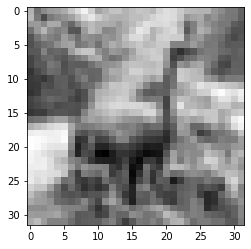

In [14]:
plt.imshow(img.mean(0), cmap='gray')
plt.show()

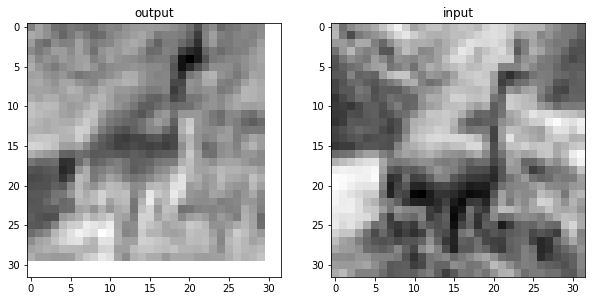

In [15]:
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
plt.savefig('Ch8_F2_PyTorch.png')  # bookskip
plt.show()

<a id="8.2.1."></a>
### 8.2.1. padding the boundary

In [16]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1) # <1> now with padding
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

![](../images/dlwpt-screenshots/dlwpt-08-03.png)

##### padding
- creating ghost pixels around the border that have value zero as far as the convolution is concerned
- means the cell (0,0) has an extra set of neighbors above it and to its left, so that an output of the convolution can be computed even in the corner of our original image
- final net result is that the output has now the exact same size as the input
    - note! padding=1 preserves image size for the case of a 3x3 kernel, i.e. padding and kernel proportionality
    - note! even-sized kernels need to be pad by different numbers on left vs right, top vs bottom
    - note! weight and bias matrix size does not change
- why do we do this?
    - separates the matters of convolution and changing image sizes
    - allows more elaborate structures such as skip connections or U-Nets

<a id="8.2S.2."></a>
### 8.2.2. detecting features with convolutions

In [17]:
with torch.no_grad():
    conv.bias.zero_()  # zero out biases
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0) # sets weight to constant value of 0.1111

- We could have gone with conv.weight.one_() —that would result in each pixel in the output being the sum of the pixels in the neighborhood. Not a big difference, except that the values in the output image would have been nine times larger
????

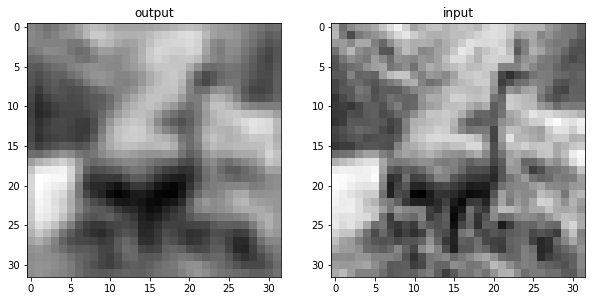

In [18]:
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
plt.savefig('Ch8_F4_PyTorch.png')  # bookskip
plt.show()

- as expected, produces blurred version of image

In [19]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]])
    # this kernel may look a bit mysterious at first...
    conv.bias.zero_()

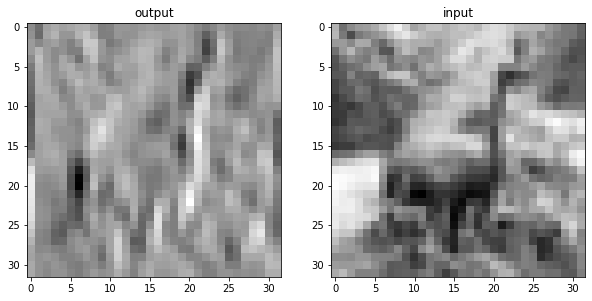

In [20]:
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
plt.savefig('Ch8_F5_PyTorch.png')  # bookskip
plt.show()

- the difference of all pixels on the right of input (2,2) minus the pixels on the left of input (2,2). If the kernel is applied on a vertical boundary between two adjacent regions of different intensity, output(2,2) will have a high value. 
- If the kernel is applied on a region of uniform intensity, output (2, 2) will be zero. 
- It’s an **edge-detection kernel**: the kernel highlights the vertical edge between two horizontally adjacent regions
- historically, the job of a computer vision expert has historically been to come up with the most effective combination of filters so that certain features are highlighted in images and objects can be recognized

![](../images/dlwpt-screenshots/dlwpt-08-06.png)

<a id="8.2.3."></a>
### 8.2.3. looking further with depth and pooling

#### problem
- what about the big picture? 
- can we use a 32x32 kernel for a 32x32 image? -- no, the point of convolution is lost
- solution: downsampling!

#### from large to small: downsampling
many different ways of doing it:
- Average the four pixels. This average pooling was a common approach early on but has fallen out of favor somewhat.
- Take the maximum of the four pixels. This approach, called max pooling, is currently the most commonly used approach, but it has a downside of discarding the other three-quarters of the data.
- Perform a strided convolution, where only every Nth pixel is calculated. A 3 × 4 convolution with stride 2 still incorporates input from all pixels from the previous layer. The literature shows promise for this approach, but it has not yet supplanted max pooling.

#### Fun Fact: Jeffrey Hinton said -- 
> "The pooling operation used in convolutional neural networks is a big mistake, and the fact that it works so well is a disaster."
- See [this blog](https://towardsdatascience.com/what-is-wrong-with-convolutional-neural-networks-75c2ba8fbd6f) for a tldr

![](../images/dlwpt-screenshots/dlwpt-08-07.png)

In [21]:
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

#### combining convolutions and downsampling for great goood

![](../images/dlwpt-screenshots/dlwpt-08-08.png)

<a id="8.2.4."></a>
### 8.2.4. putting it all together for our network

In [22]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ...
            )

In [23]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ... <1> warning: something is missing here!
            nn.Linear(8 * 8 * 8, 32),
            nn.Tanh(),
            nn.Linear(32, 2))

![](../images/dlwpt-screenshots/dlwpt-08-09.png)

In [33]:
# 3, 16, kernel_size=3
3 * 16 * 3 * 3
# in channel is the amount of kernels we have in the first model

432

In [24]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [25]:
model(img.unsqueeze(0))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x8 and 512x32)